# E2E Results Analyze

End-to-end timing analysis across `(alg, dataset, method, beams, model)` combinations.

**Per-problem reduction:** within one CSV file, each problem is generated as multiple beams in parallel — so the *wall time* for that problem is the **max** `gen_time_ms` across its beams.

**Per-config aggregation:** average those per-problem max times across all problems in the dataset.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# ---- Configuration space ---------------------------------------------------
ALGS     = ['best_of_n', 'beam_search']
DATASETS = ['MATH-500', 'AIME']
METHODS  = ['vllm', 'ours']
BEAMS_128    = [2, 4, 8, 16, 32, 64, 128]
BEAMS_64    = [2, 4, 8, 16, 32, 64]
MODELS   = ['1.5B', 'Llama-1B']

# ---- Paths -----------------------------------------------------------------
PROJECT_ROOT = Path('..').resolve()

# Display name -> on-disk subpath under data/. Both Qwen-1.5B and Llama-1B
# follow the same convention: data/{org}/{model_name}/{dataset_short}/.
MODEL_DIR = {
    '1.5B':     'Qwen/QWen2.5-1.5B-Instruct',
    'Llama-1B': 'meta-llama/Llama-3.2-1B-Instruct',
}

# Display name -> dataset folder under data/{MODEL_DIR}/.
# AIME's HF id is `AI-MO/aimo-validation-aime`, so the trace+replay scripts
# write under `aimo-validation-aime/` (= dataset_name.split('/')[-1]).
DATASET_DIR = {
    'MATH-500': 'MATH-500',
    'AIME':     'aimo-validation-aime',
}

def data_dir(dataset: str, model: str) -> Path:
    return PROJECT_ROOT / 'data' / MODEL_DIR[model] / DATASET_DIR[dataset]

def csv_path(alg: str, dataset: str, model: str, method: str, n: int) -> Path:
    """Filename pattern per algorithm. MATH-500 results were organized into
    per-algorithm subfolders (e.g. `.../MATH-500/best_of_n/...`); AIME results
    land flat under the dataset folder because the trace+replay scripts write
    directly to `data/{model}/{dataset_short_name}/`. Try the alg subfolder
    first, fall back to flat."""
    if alg == 'best_of_n':
        filename = f'best_of_n_request_timings_{method}_n{n}.csv'
    elif alg == 'beam_search':
        filename = f'beam_search_request_timings_{method}_n{n}.csv'
    elif alg == 'DVTS':
        filename = f'dvts_request_timings_{method}_n{n}.csv'
    else:
        raise ValueError(f'Unknown alg: {alg}')
    dir_ = data_dir(dataset, model)
    nested = dir_ / alg / filename
    flat   = dir_ / filename
    return nested if nested.exists() else flat

## 1. Per-file aggregation

For one CSV: group rows by `problem`, take `max(gen_time_ms)` per problem (the slowest beam = wall time for that problem), then average across all problems.

In [2]:
def avg_wall_time_ms(path: Path) -> tuple[float, int]:
    """Return (mean per-problem max gen_time_ms, num_problems). NaN if file missing."""
    if not path.exists():
        return float('nan'), 0
    df = pd.read_csv(path)
    # Detect the problem column name (best_of_n uses 'problem', helper CSVs use 'problem_idx').
    problem_col = 'problem' if 'problem' in df.columns else 'problem_idx'
    per_problem_max = df.groupby(problem_col)['gen_time_ms'].max()
    return float(per_problem_max.mean()), int(per_problem_max.size)

## 2. Sweep all `(method, beams)` combinations for a given `(alg, dataset, model)`

In [3]:
def analyze(alg: str, dataset: str, model: str) -> pd.DataFrame:
    """Build a (method x beams) table of average wall times in ms."""
    rows = []
    # 1.5B Qwen has full sweep up to n=128; Llama-1B sweep caps at n=64
    # (per LLAMA1B_SWEEP.md). Any other model defaults to BEAMS_64.
    if model == '1.5B':
        BEAMS = BEAMS_128
    else:
        BEAMS = BEAMS_64
    for method in METHODS:
        for n in BEAMS:
            p = csv_path(alg, dataset, model, method, n)
            mean_ms, n_problems = avg_wall_time_ms(p)
            rows.append({
                'method':     method,
                'beams':      n,
                'avg_ms':     mean_ms,
                'n_problems': n_problems,
                'file':       p.name if p.exists() else f'(missing) {p.name}',
            })
    long = pd.DataFrame(rows)
    pivot = long.pivot(index='method', columns='beams', values='avg_ms').reindex(METHODS)[BEAMS]
    pivot.columns = [f'n={n}' for n in pivot.columns]
    return pivot, long

## 3. Run the analysis (1.5B Model)

Pick a `(dataset, model)` and a list of algorithms to analyze. Each table shows average wall time (ms) per problem; missing files appear as `NaN`.

In [18]:
DATASET = 'MATH-500'   # 'MATH-500' | 'AIME'
MODEL   = '1.5B'

print(f'Source folder: {data_dir(DATASET, MODEL)}\n')

results = {}
for alg in ALGS:
    pivot, long = analyze(alg, DATASET, MODEL)
    results[alg] = {'pivot': pivot, 'long': long}
    print(f'=== {alg} | {DATASET} | {MODEL} — avg wall time per problem (ms) ===')
    print(pivot.round(2).to_string())
    print()

Source folder: ./data/Qwen/QWen2.5-1.5B-Instruct/MATH-500

=== best_of_n | MATH-500 | 1.5B — avg wall time per problem (ms) ===
            n=2      n=4      n=8     n=16     n=32     n=64    n=128
method                                                               
vllm    3952.81  4701.97  5312.17  5931.04  7009.17  8192.43  9962.18
ours    3418.07  4122.06  4753.03  5350.77  6210.64  7212.73  9127.16

=== beam_search | MATH-500 | 1.5B — avg wall time per problem (ms) ===
            n=2      n=4      n=8     n=16     n=32     n=64     n=128
method                                                                
vllm    3381.76  3780.47  4639.62  5249.14  6146.00  7601.81  13612.92
ours    3140.10  3332.88  4015.19  4771.52  5425.88  6708.33  11297.17



## 4. Visualize best_of_n results (1.5B Model)

Latency vs beams (log-log).

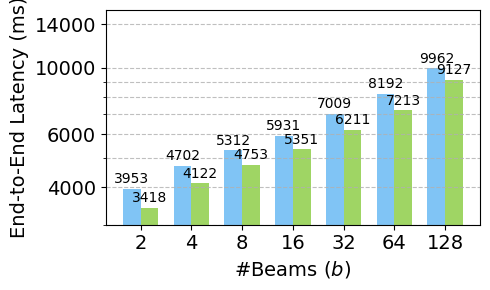

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter, ScalarFormatter

pivot = results['best_of_n']['pivot']

COLORS = {'vllm': '#80c4f5', 'ours': '#9fd564'}

x = np.arange(len(BEAMS_128))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))
for i, method in enumerate(METHODS):
    offset = (i - (len(METHODS) - 1) / 2) * width
    vals = pivot.loc[method].values
    bars = ax.bar(x + offset, vals, width, label=method, color=COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
ax.set_ylim(3000, 15600)
ax.set_yticks([4000, 6000, 10000, 14000])
# ax.set_ylim(5000, 43000)
# ax.set_yticks([10000, 20000, 30000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.tick_params(axis='both', labelsize=14)
ax.set_xticklabels([str(n) for n in BEAMS_128])
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=14)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=14)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()
(PROJECT_ROOT / 'figures').mkdir(exist_ok=True)
fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bon_MATH500_QWen.png',
            dpi=300, bbox_inches='tight')
# fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bon_AIME_QWen.png',
#             dpi=300, bbox_inches='tight')
plt.show()

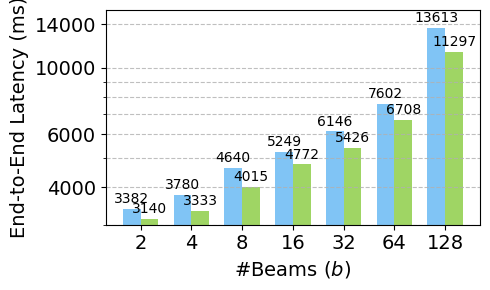

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

pivot = results['beam_search']['pivot']

COLORS = {'vllm': '#80c4f5', 'ours': '#9fd564'}

x = np.arange(len(BEAMS_128))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))
for i, method in enumerate(METHODS):
    offset = (i - (len(METHODS) - 1) / 2) * width
    vals = pivot.loc[method].values
    bars = ax.bar(x + offset, vals, width, label=method, color=COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
ax.set_ylim(3000, 15600)
ax.set_yticks([4000, 6000, 10000, 14000])
# ax.set_ylim(5000, 43000)
# ax.set_yticks([10000, 20000, 30000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in BEAMS_128])
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=14)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=14)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()
(PROJECT_ROOT / 'figures').mkdir(exist_ok=True)
fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bs_MATH500_QWen.png',
            dpi=300, bbox_inches='tight')
# fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bs_AIME_QWen.png',
#             dpi=300, bbox_inches='tight')
plt.show()

## 5. Run the analysis (Llama-1B Model)

Pick a `(dataset, model)` and a list of algorithms to analyze. Each table shows average wall time (ms) per problem; missing files appear as `NaN`.

In [15]:
DATASET = 'AIME'   # 'MATH-500' | 'AIME'
MODEL   = 'Llama-1B'

print(f'Source folder: {data_dir(DATASET, MODEL)}\n')

results = {}
for alg in ALGS:
    pivot, long = analyze(alg, DATASET, MODEL)
    results[alg] = {'pivot': pivot, 'long': long}
    print(f'=== {alg} | {DATASET} | {MODEL} — avg wall time per problem (ms) ===')
    print(pivot.round(2).to_string())
    print()

Source folder: ./data/meta-llama/Llama-3.2-1B-Instruct/aimo-validation-aime

=== best_of_n | AIME | Llama-1B — avg wall time per problem (ms) ===
            n=2      n=4       n=8      n=16      n=32      n=64
method                                                          
vllm    8117.45  9927.42  14738.36  18535.95  21345.84  24602.12
ours    6580.74  7951.53  11067.31  13809.51  16264.93  19683.10

=== beam_search | AIME | Llama-1B — avg wall time per problem (ms) ===
            n=2      n=4       n=8      n=16      n=32      n=64
method                                                          
vllm    5428.77  8025.47  10409.51  12830.63  16856.38  20488.90
ours    4701.73  6512.60   8277.81   9913.94  12890.80  15831.82



## 6. Visualize best_of_n results (Llama-1B Model)

Latency vs beams (log-log).

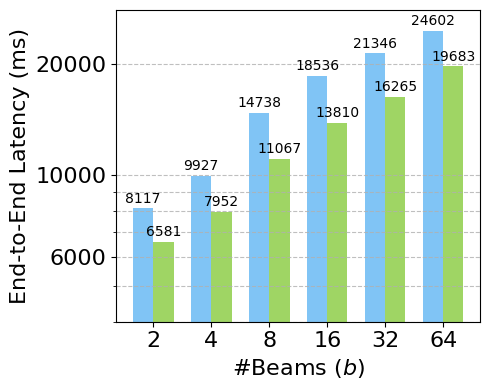

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

pivot = results['best_of_n']['pivot']

COLORS = {'vllm': '#80c4f5', 'ours': '#9fd564'}

x = np.arange(len(BEAMS_64))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 4))
for i, method in enumerate(METHODS):
    offset = (i - (len(METHODS) - 1) / 2) * width
    vals = pivot.loc[method].values
    bars = ax.bar(x + offset, vals, width, label=method, color=COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
# ax.set_ylim(2000, 13000)
# ax.set_yticks([4000, 6000, 10000])
ax.set_ylim(4000, 28000)
ax.set_yticks([6000, 10000, 20000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in BEAMS_64])
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=16)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=16)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()
(PROJECT_ROOT / 'figures').mkdir(exist_ok=True)
# fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bon_MATH500_Llama.png',
#             dpi=300, bbox_inches='tight')
fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bon_AIME_Llama.png',
            dpi=300, bbox_inches='tight')
plt.show()

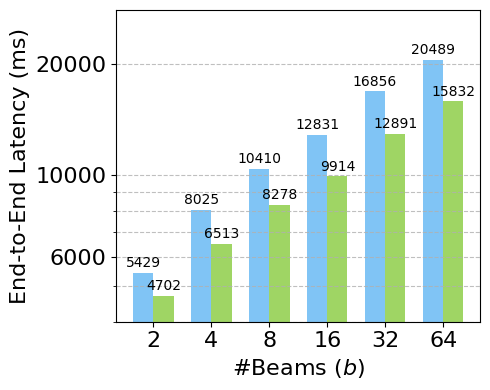

In [20]:
pivot = results['beam_search']['pivot']

COLORS = {'vllm': '#80c4f5', 'ours': '#9fd564'}

x = np.arange(len(BEAMS_64))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 4))
for i, method in enumerate(METHODS):
    offset = (i - (len(METHODS) - 1) / 2) * width
    vals = pivot.loc[method].values
    bars = ax.bar(x + offset, vals, width, label=method, color=COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
# ax.set_ylim(2000, 13000)
# ax.set_yticks([4000, 6000, 10000])
ax.set_ylim(4000, 28000)
ax.set_yticks([6000, 10000, 20000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in BEAMS_64])
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=16)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=16)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()
(PROJECT_ROOT / 'figures').mkdir(exist_ok=True)
# fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bs_MATH500_Llama.png',
#             dpi=300, bbox_inches='tight')
fig.savefig(PROJECT_ROOT / 'figures' / 'e2e_results_bs_AIME_Llama.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 7. Qwen-2.5-7B results

These cells read one explicit data mode (`replay` or `no_replay`), compute average per-problem wall time, and report `latency(vllm) / latency(ours)` speedups. MATH-500 and AIME are plotted separately so each figure can tune its own visual parameters.


In [40]:
# --- 7. Qwen-2.5-7B: load timing data and compute speedups ------------
# Choose the data mode explicitly before reading files: 'replay' or 'no_replay'.
QWEN7B_REPLAY_MODE = 'no_replay'
assert QWEN7B_REPLAY_MODE in {'replay', 'no_replay'}

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import NullFormatter, ScalarFormatter

QWEN7B_MODEL_DIR = Path('./data/Qwen/Qwen2.5-7B-Instruct')
QWEN7B_FIG_DIR = Path('./figures')
QWEN7B_FIG_DIR.mkdir(parents=True, exist_ok=True)

QWEN7B_DATASET_DIR = {
    'MATH-500': 'MATH-500',
    'AIME': 'aimo-validation-aime',
}
QWEN7B_ALGS = ['best_of_n', 'beam_search']
QWEN7B_ALG_SHORT = {'best_of_n': 'bon', 'beam_search': 'bs'}
QWEN7B_METHODS = ['vllm', 'ours']
QWEN7B_BEAMS = [2, 4, 8, 16, 32, 64, 128]
QWEN7B_COLORS = {'vllm': '#80c4f5', 'ours': '#9fd564'}

qwen7b_rows = []
for dataset, dataset_dir in QWEN7B_DATASET_DIR.items():
    for alg in QWEN7B_ALGS:
        for method in QWEN7B_METHODS:
            for n in QWEN7B_BEAMS:
                if alg == 'best_of_n':
                    filename = f'best_of_n_request_timings_{method}_n{n}.csv'
                elif alg == 'beam_search':
                    filename = f'beam_search_request_timings_{method}_n{n}.csv'
                path = QWEN7B_MODEL_DIR / dataset_dir / QWEN7B_REPLAY_MODE / filename

                if path.exists():
                    one = pd.read_csv(path)
                    problem_col = 'problem' if 'problem' in one.columns else 'problem_idx'
                    per_problem_max = one.groupby(problem_col)['gen_time_ms'].max()
                    avg_ms = float(per_problem_max.mean())
                    n_problems = int(per_problem_max.size)
                else:
                    avg_ms = np.nan
                    n_problems = 0

                qwen7b_rows.append({
                    'dataset': dataset,
                    'alg': alg,
                    'mode': QWEN7B_REPLAY_MODE,
                    'method': method,
                    'beams': n,
                    'avg_ms': avg_ms,
                    'n_problems': n_problems,
                    'file': str(path),
                })

qwen7b_long = pd.DataFrame(qwen7b_rows)
qwen7b_results = {}
qwen7b_speedup_rows = []

print('7B source root:', QWEN7B_MODEL_DIR)
print('data mode     :', QWEN7B_REPLAY_MODE)

for dataset in QWEN7B_DATASET_DIR:
    print(f'\n===== {dataset} =====')
    qwen7b_results[dataset] = {}
    for alg in QWEN7B_ALGS:
        sub = qwen7b_long[(qwen7b_long['dataset'] == dataset) & (qwen7b_long['alg'] == alg)]
        latency = sub.pivot(index='method', columns='beams', values='avg_ms')
        latency = latency.reindex(index=QWEN7B_METHODS, columns=QWEN7B_BEAMS)
        speedup = latency.loc['vllm'] / latency.loc['ours']
        speedup.name = 'speedup_vllm_over_ours'
        qwen7b_results[dataset][alg] = {'latency': latency, 'speedup': speedup}

        print(f'\n--- {alg}: avg wall time per problem (ms) ---')
        print(latency.round(2).to_string())
        print('\nSpeedup = latency(vllm) / latency(ours)')
        print(speedup.round(3).to_string())

        for n, value in speedup.items():
            qwen7b_speedup_rows.append({
                'dataset': dataset,
                'alg': alg,
                'mode': QWEN7B_REPLAY_MODE,
                'beams': n,
                'speedup_vllm_over_ours': value,
            })

qwen7b_speedups = pd.DataFrame(qwen7b_speedup_rows)
qwen7b_speedup_table = qwen7b_speedups.pivot_table(
    index=['dataset', 'alg', 'mode'],
    columns='beams',
    values='speedup_vllm_over_ours',
)
print('\n===== Qwen-2.5-7B speedup summary =====')
display(qwen7b_speedup_table.round(3))


7B source root: ./data/Qwen/Qwen2.5-7B-Instruct
data mode     : no_replay

===== MATH-500 =====

--- best_of_n: avg wall time per problem (ms) ---
beams       2        4        8        16       32        64        128
method                                                                 
vllm    6164.32  6746.32  7923.11  8772.64  9594.48  11314.94  14921.48
ours    5702.25  6210.41  6686.86  7549.95  8445.88   9652.62  12667.27

Speedup = latency(vllm) / latency(ours)
beams
2      1.081
4      1.086
8      1.185
16     1.162
32     1.136
64     1.172
128    1.178

--- beam_search: avg wall time per problem (ms) ---
beams       2        4        8        16       32        64        128
method                                                                 
vllm    5323.98  5440.77  7015.92  7680.65  8970.37  10617.03  13710.02
ours    4715.23  4832.75  6045.18  6642.74  7801.28   9137.66  12290.57

Speedup = latency(vllm) / latency(ours)
beams
2      1.129
4      1.126
8      1.161


beams                             2      4      8      16     32     64   \
dataset  alg         mode                                                  
AIME     beam_search no_replay  1.243  1.251  1.276  1.272  1.241  1.223   
         best_of_n   no_replay  1.257  1.252  1.334  1.312  1.267  1.221   
MATH-500 beam_search no_replay  1.129  1.126  1.161  1.156  1.150  1.162   
         best_of_n   no_replay  1.081  1.086  1.185  1.162  1.136  1.172   

beams                             128  
dataset  alg         mode              
AIME     beam_search no_replay  1.152  
         best_of_n   no_replay  1.153  
MATH-500 beam_search no_replay  1.115  
         best_of_n   no_replay  1.178

saved: ./figures/e2e_results_bon_MATH500_Qwen7B_no_replay.png

Speedup = latency(vllm) / latency(ours)
beams
2      1.081
4      1.086
8      1.185
16     1.162
32     1.136
64     1.172
128    1.178


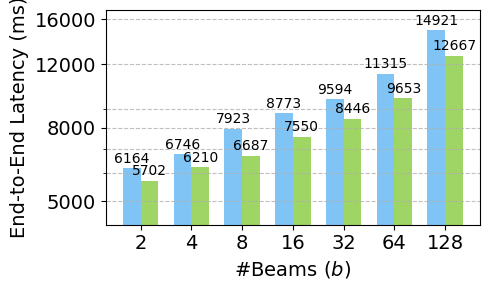

In [48]:
# --- 7. Qwen-2.5-7B: MATH-500 best_of_n latency ----------------------
dataset = 'MATH-500'
alg = 'best_of_n'
pivot = qwen7b_results[dataset][alg]['latency']
speedup = qwen7b_results[dataset][alg]['speedup']

beams = [n for n in QWEN7B_BEAMS if not pivot[n].isna().all()]
x = np.arange(len(beams))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))
for i, method in enumerate(QWEN7B_METHODS):
    offset = (i - (len(QWEN7B_METHODS) - 1) / 2) * width
    vals = pivot.loc[method, beams].values
    bars = ax.bar(x + offset, vals, width, label=method, color=QWEN7B_COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
ax.set_ylim(4300, 17000)
ax.set_yticks([5000, 8000, 12000, 16000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in beams])
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=14)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=14)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()

out_path = QWEN7B_FIG_DIR / f'e2e_results_bon_MATH500_Qwen7B_{QWEN7B_REPLAY_MODE}.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print('saved:', out_path)
print()
print('Speedup = latency(vllm) / latency(ours)')
print(speedup.round(3).to_string())
plt.show()


saved: ./figures/e2e_results_bs_MATH500_Qwen7B_no_replay.png

Speedup = latency(vllm) / latency(ours)
beams
2      1.129
4      1.126
8      1.161
16     1.156
32     1.150
64     1.162
128    1.115


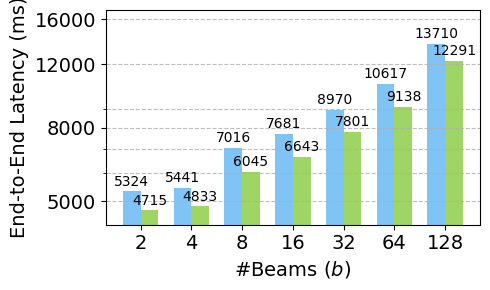

In [47]:
# --- 7. Qwen-2.5-7B: MATH-500 beam_search latency ----------------------
dataset = 'MATH-500'
alg = 'beam_search'
pivot = qwen7b_results[dataset][alg]['latency']
speedup = qwen7b_results[dataset][alg]['speedup']

beams = [n for n in QWEN7B_BEAMS if not pivot[n].isna().all()]
x = np.arange(len(beams))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))
for i, method in enumerate(QWEN7B_METHODS):
    offset = (i - (len(QWEN7B_METHODS) - 1) / 2) * width
    vals = pivot.loc[method, beams].values
    bars = ax.bar(x + offset, vals, width, label=method, color=QWEN7B_COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
ax.set_ylim(4300, 17000)
ax.set_yticks([5000, 8000, 12000, 16000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in beams])
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=14)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=14)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()

out_path = QWEN7B_FIG_DIR / f'e2e_results_bs_MATH500_Qwen7B_{QWEN7B_REPLAY_MODE}.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print('saved:', out_path)
print()
print('Speedup = latency(vllm) / latency(ours)')
print(speedup.round(3).to_string())
plt.show()


saved: ./figures/e2e_results_bon_AIME_Qwen7B_no_replay.png

Speedup = latency(vllm) / latency(ours)
beams
2      1.257
4      1.252
8      1.334
16     1.312
32     1.267
64     1.221
128    1.153


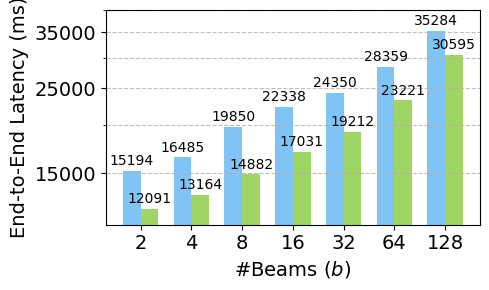

In [55]:
# --- 7. Qwen-2.5-7B: AIME best_of_n latency ----------------------
dataset = 'AIME'
alg = 'best_of_n'
pivot = qwen7b_results[dataset][alg]['latency']
speedup = qwen7b_results[dataset][alg]['speedup']

beams = [n for n in QWEN7B_BEAMS if not pivot[n].isna().all()]
x = np.arange(len(beams))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))
for i, method in enumerate(QWEN7B_METHODS):
    offset = (i - (len(QWEN7B_METHODS) - 1) / 2) * width
    vals = pivot.loc[method, beams].values
    bars = ax.bar(x + offset, vals, width, label=method, color=QWEN7B_COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
ax.set_ylim(11000, 40000)
ax.set_yticks([15000, 25000, 35000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in beams])
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=14)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=14)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()

out_path = QWEN7B_FIG_DIR / f'e2e_results_bon_AIME_Qwen7B_{QWEN7B_REPLAY_MODE}.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print('saved:', out_path)
print()
print('Speedup = latency(vllm) / latency(ours)')
print(speedup.round(3).to_string())
plt.show()


saved: ./figures/e2e_results_bs_AIME_Qwen7B_no_replay.png

Speedup = latency(vllm) / latency(ours)
beams
2      1.243
4      1.251
8      1.276
16     1.272
32     1.241
64     1.223
128    1.152


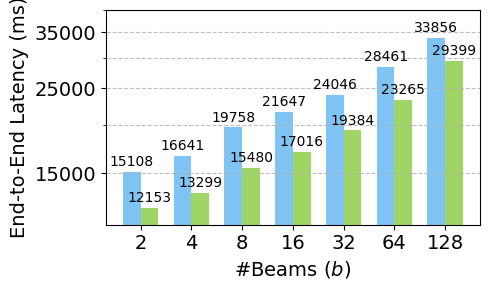

In [56]:
# --- 7. Qwen-2.5-7B: AIME beam_search latency ----------------------
dataset = 'AIME'
alg = 'beam_search'
pivot = qwen7b_results[dataset][alg]['latency']
speedup = qwen7b_results[dataset][alg]['speedup']

beams = [n for n in QWEN7B_BEAMS if not pivot[n].isna().all()]
x = np.arange(len(beams))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3))
for i, method in enumerate(QWEN7B_METHODS):
    offset = (i - (len(QWEN7B_METHODS) - 1) / 2) * width
    vals = pivot.loc[method, beams].values
    bars = ax.bar(x + offset, vals, width, label=method, color=QWEN7B_COLORS[method])
    ax.bar_label(bars, fmt='%.0f', fontsize=10, padding=2)

ax.set_yscale('log')
ax.set_ylim(11000, 40000)
ax.set_yticks([15000, 25000, 35000])
_sf = ScalarFormatter()
_sf.set_scientific(False)
ax.yaxis.set_major_formatter(_sf)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in beams])
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel(r'#Beams ($\mathit{b}$)', fontsize=14)
ax.set_ylabel('End-to-End Latency (ms)', fontsize=14)
ax.grid(True, axis='y', which='both', linestyle='--', alpha=0.8)
plt.tight_layout()

out_path = QWEN7B_FIG_DIR / f'e2e_results_bs_AIME_Qwen7B_{QWEN7B_REPLAY_MODE}.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print('saved:', out_path)
print()
print('Speedup = latency(vllm) / latency(ours)')
print(speedup.round(3).to_string())
plt.show()
